# 🧠 Análisis Exploratorio del Dataset: Stroke Prediction
**Objetivo:** Explorar los datos crudos, identificar inconsistencias ocultas (como los valores "Unknown" en el estado de tabaquismo) y definir un flujo de limpieza y transformación riguroso para predecir accidentes cerebrovasculares, que luego llevaremos a nuestro entorno local en VS Code para construir el pipeline [1, 2].

**Diccionario de Variables Clave:**
* `id`: Identificador único del paciente.
* `gender`: Género del paciente ("Male", "Female" u "Other").
* `age`: Edad del paciente.
* `hypertension`: ¿El paciente tiene hipertensión? (0 = no, 1 = sí).
* `heart_disease`: ¿El paciente tiene alguna enfermedad cardíaca? (0 = no, 1 = sí).
* `ever_married`: ¿El paciente se ha casado alguna vez? ("No" o "Yes").
* `work_type`: Tipo de empleo ("children", "Govt_jov", "Never_worked", "Private" o "Self-employed").
* `Residence_type`: Tipo de entorno de residencia ("Rural" o "Urban").
* `avg_glucose_level`: Nivel promedio de glucosa en la sangre.
* `bmi`: Índice de masa corporal (Body Mass Index).
* `smoking_status`: Condición de tabaquismo ("formerly smoked", "never smoked", "smokes" o "Unknown"*).
* `stroke`: **Variable Objetivo.** ¿El paciente tuvo un accidente cerebrovascular? (1 = sí, 0 = no).

El ataque ataque cerebrovascular (ACV), o ictus, es una emergencia médica que ocurre cuando el flujo sanguíneo al cerebro se detiene (isquémico) o un vaso sanguíneo se rompe (hemorrágico), matando células cerebrales por falta de oxígeno. según la Organización Mundial de la Salud (OMS), el ictus es *la segunda causa principal de muerte* a nivel mundial, responsable de aproximadamente el 11 % del total de fallecimientos.

Este conjunto de datos se utiliza para predecir la probabilidad de que un paciente sufra un accidente cerebrovascular, basándose en parámetros como el sexo, la edad, diversas enfermedades y el tabaquismo. Cada fila de los datos proporciona información relevante sobre el paciente.

---

## 1. Primer vistazo al DataSet.

Se realiza importación de dependencias.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Se trae el dataset en cuestión.

In [5]:
# Cargamos el dataset
df = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 1.1 Estadísticas Descriptivas y Detección de Varianza Cero
Se realiza una evaluación del dataset para conocer sus distribuciones estadísticas preliminares y detectar si existen variables con varianza cero (un único valor), las cuales no aportan poder predictivo y deberían ser candidatas a ser eliminadas por el Data Engineer o mediante un transformer custom (DropZeroVarianceTransformer).

In [6]:
# Estadísticas descriptivas generales
display(df.describe(include='all'))

# Detección de Varianza Cero: Columnas donde todos los registros tienen exactamente el mismo valor
zero_variance_cols = [col for col in df.columns if df[col].nunique() == 1]
if len(zero_variance_cols) == 0:
    print('Columnas con varianza cero (candidatas a DropZeroVarianceTransformer): Ninguna detectada. Todas las variables aportan información (tienen >1 valor único).')
else:
    print('Columnas con varianza cero:', zero_variance_cols)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


Columnas con varianza cero (candidatas a DropZeroVarianceTransformer): Ninguna detectada. Todas las variables aportan información (tienen >1 valor único).


### 1.2 Verificación de Integridad y Procedencia de Datos
A continuación, realizamos comprobaciones de calidad críticas en los datos para asegurar la confiabilidad del dataset antes de realizar imputaciones (Integridad de los datos):
- Validar si existen filas completamente duplicadas.
- Validar rangos lógicos esperados para las variables numéricas clave, como edad (0 a 120) o nivel de glucosa (> 0).
- Validar que las categorías contenidas en variables como el género coincidan con las esperadas ('Male', 'Female', 'Other').

In [7]:
# 1. Validar filas duplicadas totales
duplicates = df.duplicated().sum()
print(f'Filas duplicadas: {duplicates}')

# 2. Validar rangos lógicos (edad entre 0 y 120)
valid_age_mask = df['age'].isna() | ((df['age'] >= 0) & (df['age'] <= 120))
invalid_age = (~valid_age_mask).sum()
print(f'Registros con edad fuera de rango lógico (0-120): {invalid_age}')

# Validar rangos lógicos (glucosa > 0)
valid_glucose_mask = df['avg_glucose_level'].isna() | (df['avg_glucose_level'] > 0)
invalid_glucose = (~valid_glucose_mask).sum()
print(f'Registros con glucosa fuera de rango lógico (>0): {invalid_glucose}')

# 3. Validar categorías esperadas en gender
expected_genders = ['Male', 'Female', 'Other']
unexpected_gender = df[~df['gender'].isin(expected_genders)]['gender'].unique()
unexpected_gender = [g for g in unexpected_gender if str(g) != 'nan']
if len(unexpected_gender) == 0:
    print('Categorías extrañas en gender detectadas: Ninguna. Todos los registros cumplen con el diccionario de datos.')
else:
    print(f'Categorías extrañas en gender no consideradas en el diccionario: {unexpected_gender}')

Filas duplicadas: 0
Registros con edad fuera de rango lógico (0-120): 0
Registros con glucosa fuera de rango lógico (>0): 0
Categorías extrañas en gender detectadas: Ninguna. Todos los registros cumplen con el diccionario de datos.


### 1.3 Optimización de Memoria (Downcasting)
Para garantizar el mejor rendimiento posible en fases posteriores y cumplir con requerimientos estrictos de eficiencia, se reduce la huella de memoria (Downcasting) de las variables cambiando sus tipos de dato a formatos más ligeros en donde es analíticamente seguro (Ej: float64 a float32).

In [8]:
# Revisar uso de memoria inicial en Megabytes
mem_before = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memoria inicial del DataFrame: {mem_before:.2f} MB')

# Downcasting de tipos para optimizar memoria RAM
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32') # Precisión suficiente para numéricas continuas

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

# Revisar uso de memoria después del refactor
mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memoria final del DataFrame: {mem_after:.2f} MB')
print(f'Ahorro de memoria conseguido en la transformación: {(1 - mem_after/mem_before)*100:.2f}%')

Memoria inicial del DataFrame: 1.62 MB
Memoria final del DataFrame: 1.44 MB
Ahorro de memoria conseguido en la transformación: 11.14%


## 2. Estandarización de Nulos.

Antes de realizar el conteo total de valores faltantes, tales como 'Unknown' o 'NaN', es necesario aplicar una transformación que permita estandarizar dichos campos. Por ejemplo, si en una columna tenemos un valor oculto de tipo 'na' y en otra 'unknown' (en minúsculas), se debe conservar una única identificación para el valor nulo. Esto es crucial tanto para la precisión del análisis matemático como para su correcta exposición gráfica.

In [9]:
# 1. Definimos los valores basura
valores_basura = ['unknown', 'Unknown', 'UNKNOWN', 'na', 'NA']

Se reemplaza todo lo que pueda ser un valor faltante por un tipo de dato "NaN" de la libreria Numpy, para estandarizar el dataframe.

**Justificación Técnica de la Limpieza:** Se estandarizan los valores nulos (tales como 'Unknown', 'N/A', 'na', etc.) a `np.nan` porque esto es un paso mandatorio para que librerías como Pandas y Scikit-Learn reconozcan los registros uniformemente como datos faltantes del sistema. Con este estándar garantizado, el Pipeline luego podrá utilizar sin problemas técnicas formales de imputación como `SimpleImputer` en Scikit-Learn, o usar métodos nativos robustos minimizando errores silenciosos.

In [10]:
df = df.replace(valores_basura, np.nan)

In [11]:
print("--- Conteo de 'NaN' por columna ---")
# Suma todos los NaN
count_nan = df.isnull().sum()

print(count_nan[count_nan > 0].sort_values(ascending=False))

--- Conteo de 'NaN' por columna ---
smoking_status    1544
bmi                201
dtype: int64


Se crea un mapa de calor para visualización de datos.

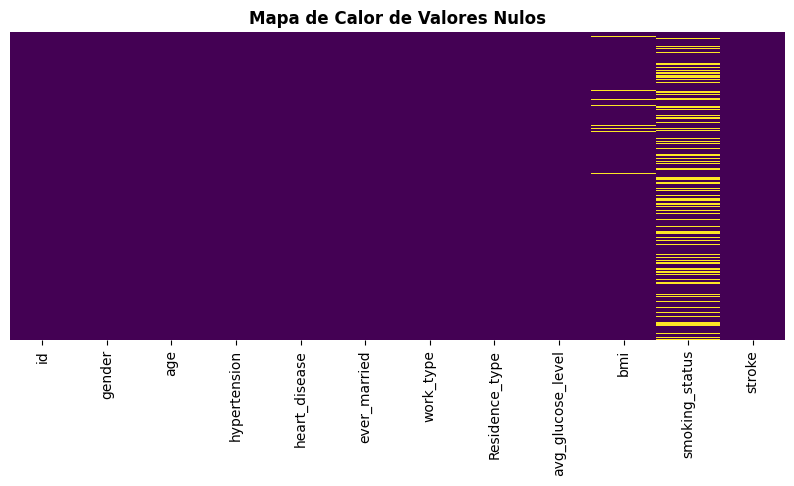

In [13]:
# Mapa de Calor Optimizado para valores nulos
plt.figure(figsize=(10, 4))

# Usamos df.isnull() para que evalúe si es True (nulo) o False (dato válido)
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)

plt.title("Mapa de Calor de Valores Nulos", fontweight='bold')

# Guardar el gráfico
plt.savefig('../outputs/graficos/null_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


Podemos darnos cuenta que la variable `smoking_status` posee una gran cantidad de valores `NaN`, por lo que se evalua si mantener dicha columna es factible o no basado en la proporción.

## 3. Variable Objetivo: `stroke`
**¿El paciente sufrió un ataque cerebrovascular?**

En nuestro conjunto de datos, la variable a predecir (target) es `stroke`. Es una variable de clasificación binaria que indica el historial médico del paciente respecto a esta afección:
* **`1`**: El paciente **sí** sufrió un ataque cerebrovascular.
* **`0`**: El paciente **no** sufrió un ataque cerebrovascular.

Realizaremos un gráfico que nos permitira analizar la proporción de esta variable.

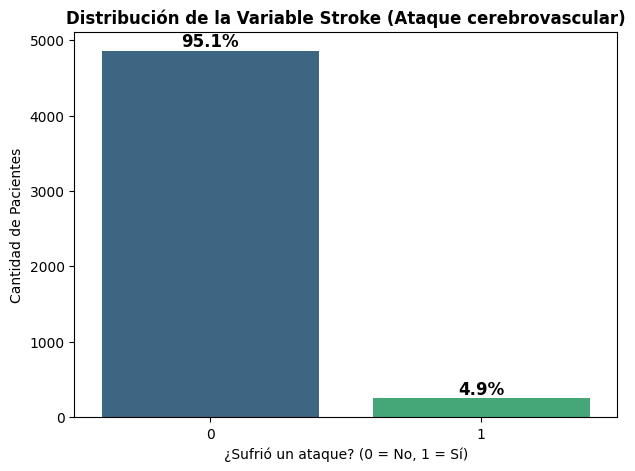

In [14]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='stroke', palette='viridis')
plt.title('Distribución de la Variable Stroke (Ataque cerebrovascular)', fontweight='bold')
plt.ylabel('Cantidad de Pacientes')
plt.xlabel('¿Sufrió un ataque? (0 = No, 1 = Sí)')

# Agregar los porcentajes arriba de las barras
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()

**Análisis e Interpretación (Variable `stroke`):** 
La variable objetivo presenta un claro **desbalance de clases**. La abrumadora mayoría de los registros en el dataset corresponden a pacientes que no sufrieron un ACV (0), siendo la minoría los casos positivos (1). Esto impacta directamente en las métricas de clasificación, lo que sugiere como Hallazgo del EDA que el equipo de modelamiento deberá incorporar de forma mandatoria una estrategia de balanceo. Opciones viables para contrarrestarlo incluyen: Sobremuestreo sintético (SMOTE), submuestreo de la clase mayoritaria (UnderSampling), o el ajuste de penalización de pesos en el hiperparámetro `class_weight='balanced'` en los clasificadores Scikit-Learn.

## 4. EDA

Para agilizar nuestro Análisis Exploratorio de Datos (EDA) y evitar la repetición de código, hemos diseñado una función automatizada llamada `plot_numeric_distributions`. 

En lugar de crear un gráfico individual para cada variable, esta función escanea el conjunto de datos, identifica todas las columnas numéricas relevantes y genera una cuadrícula (grid) de histogramas de densidad. Al superponer la distribución de los datos según la variable objetivo (`stroke`), podemos identificar de un vistazo qué factores (como la edad o el nivel de glucosa) tienen mayor impacto en los ataques cerebrovasculares.

Generando distribuciones numéricas...


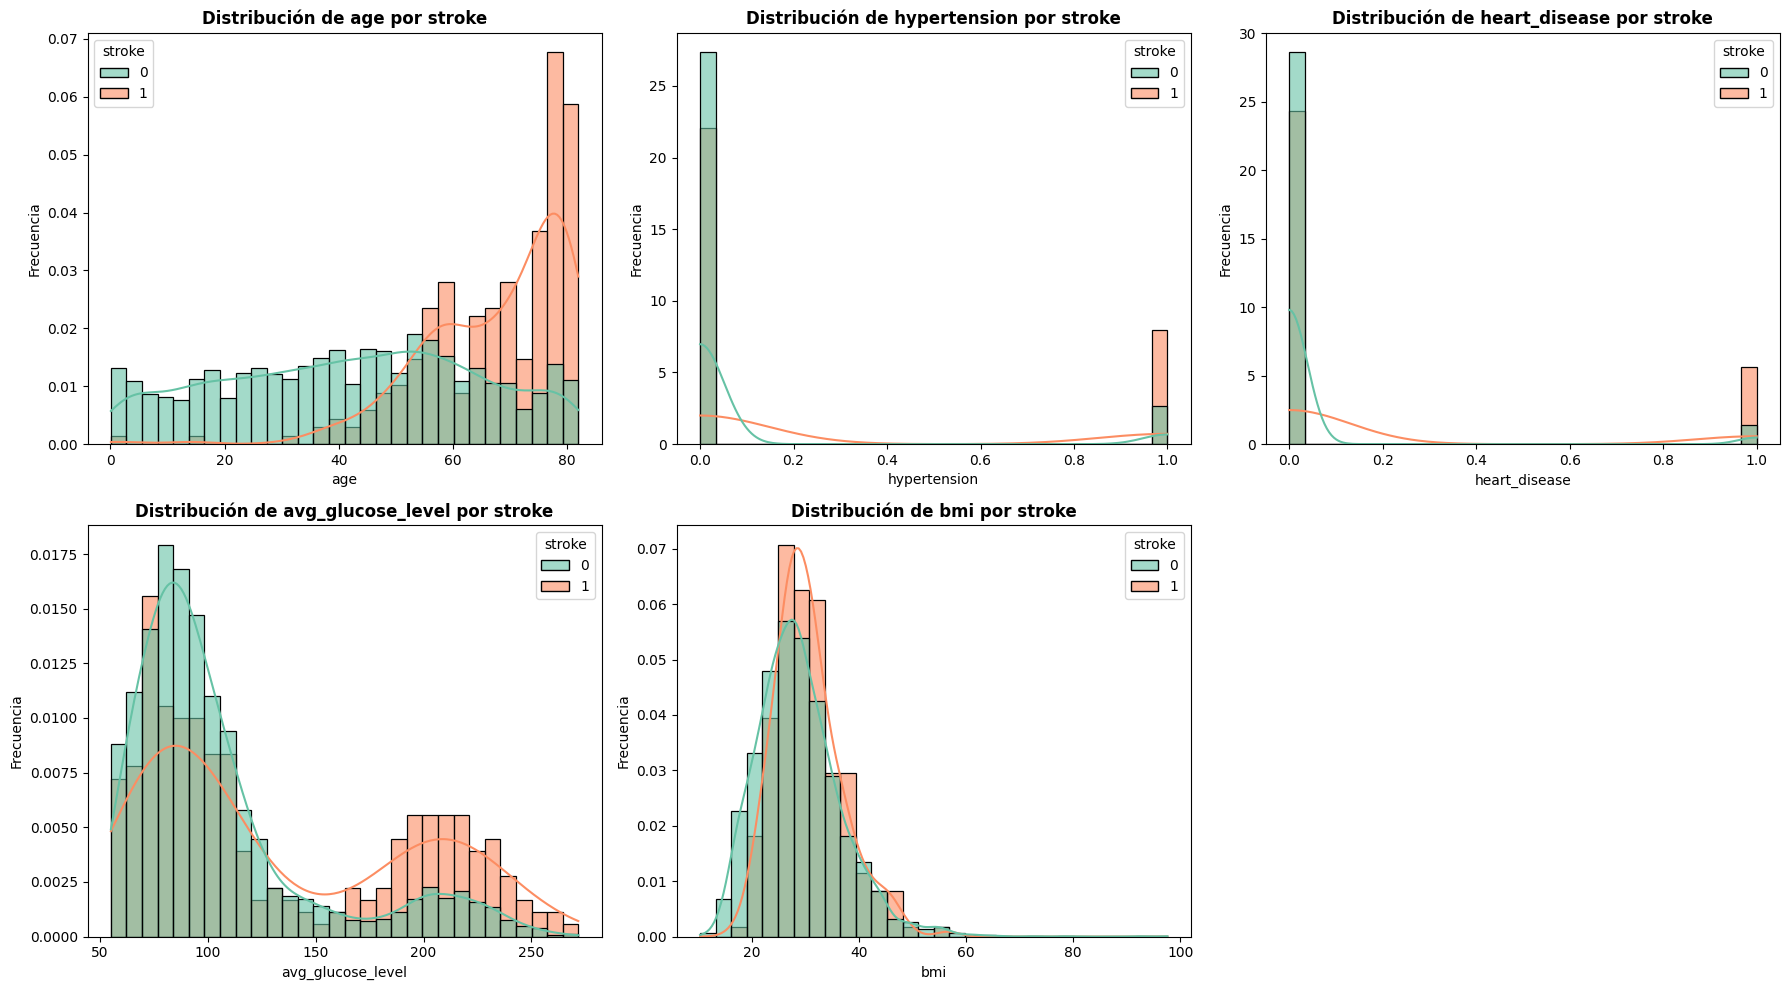


Generando frecuencias categóricas...


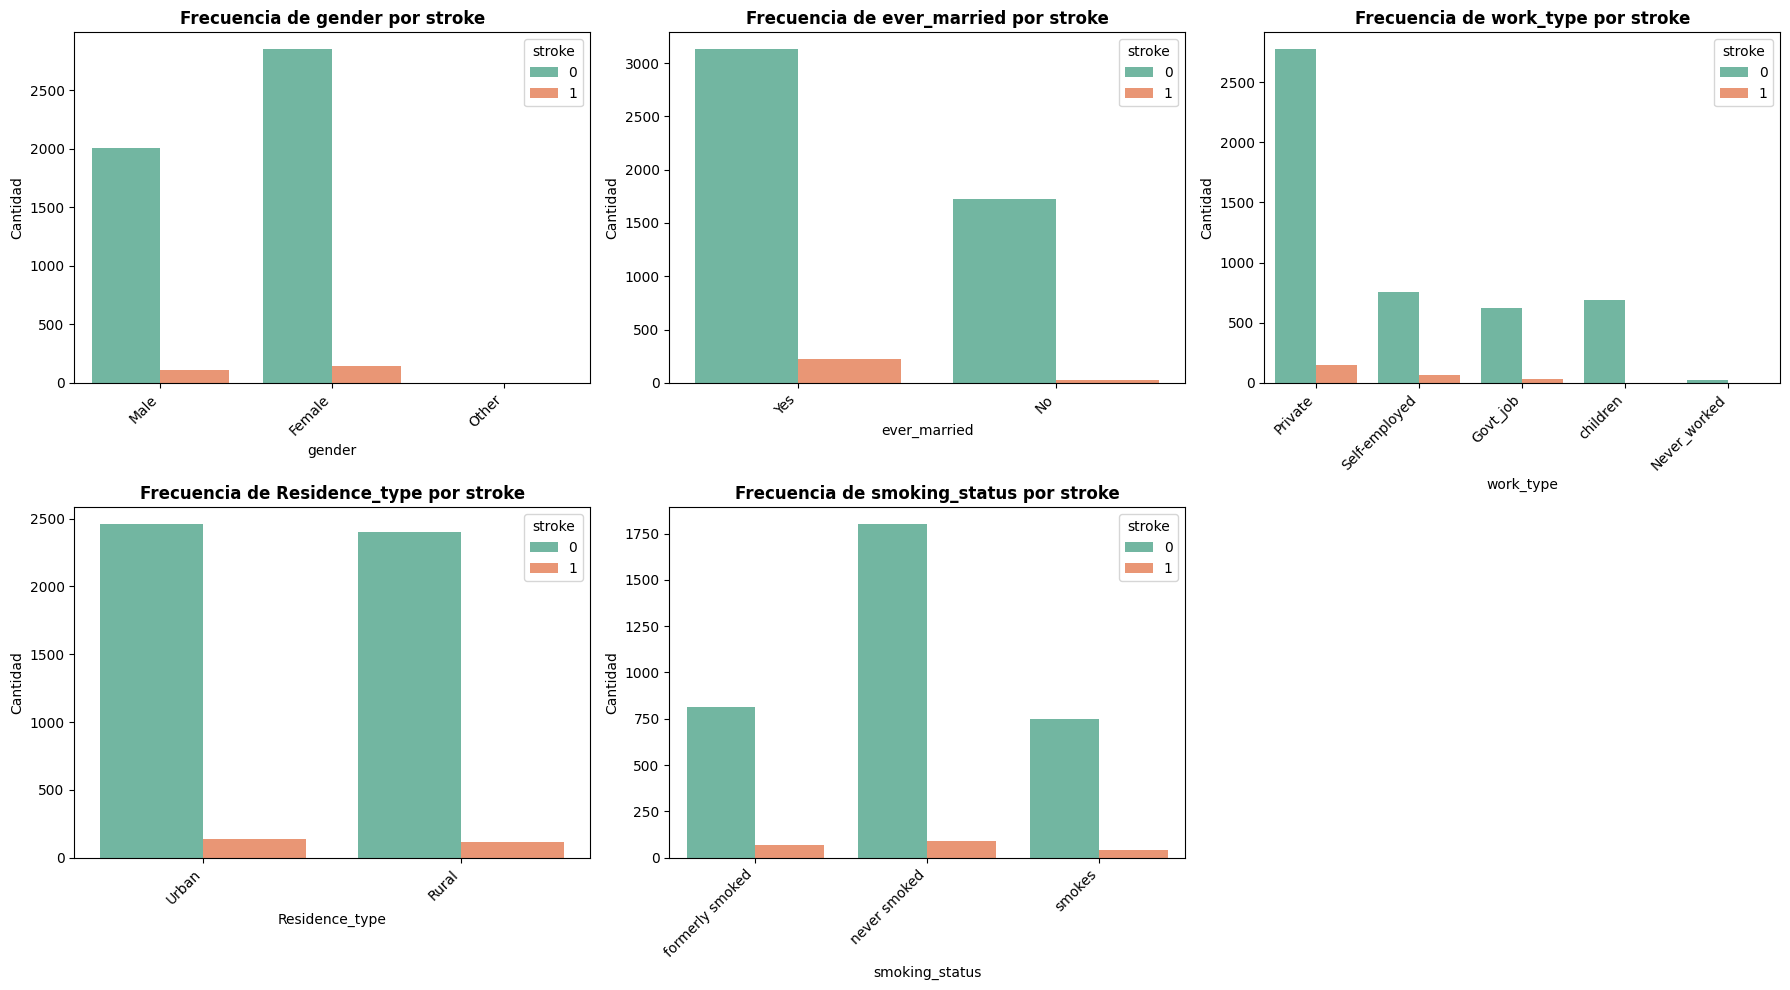

In [15]:
def plot_numeric_distributions(df, target_col):
    """Genera histogramas superpuestos para variables numéricas."""
    # 1. Detectar variables numéricas
    num_cols = df.select_dtypes(include=['number']).columns
    
    # 2. ADAPTACIÓN: Excluimos 'id' porque no aporta valor predictivo y el target
    num_cols = [c for c in num_cols if c != target_col and c != 'id']

    n_cols = 3
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        # Histograma separado por colores según si tuvo ataque o no
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[i],
                     bins=30, alpha=0.6, stat='density', common_norm=False, palette='Set2')
        axes[i].set_title(f'Distribución de {col} por {target_col}', fontweight='bold')
        axes[i].set_ylabel('Frecuencia')

    # Eliminar subplots vacíos si los hay
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    
    # 3. ADAPTACIÓN OBLIGATORIA: Guardar gráfico en la carpeta correcta
    plt.savefig('../outputs/graficos/distribuciones_numericas.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_categorical_counts(df, target_col):
    """Genera gráficos de barras para variables categóricas."""
    # 1. Detectar variables categóricas (textos)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    cat_cols = [c for c in cat_cols if c != target_col]

    n_cols = 3
    n_rows = int(np.ceil(len(cat_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        sns.countplot(data=df, x=col, hue=target_col, ax=axes[i], palette="Set2")
        axes[i].set_title(f'Frecuencia de {col} por {target_col}', fontweight='bold')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        axes[i].set_ylabel('Cantidad')

    # Eliminar subplots vacíos si los hay
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    
    # 3. ADAPTACIÓN OBLIGATORIA: Guardar gráfico en la carpeta correcta
    plt.savefig('../outputs/graficos/frecuencias_categoricas.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- EJECUCIÓN DEL CÓDIGO ---

print("Generando distribuciones numéricas...")
# Apuntamos a nuestra variable objetivo real: 'stroke'
plot_numeric_distributions(df, target_col='stroke')

print("\nGenerando frecuencias categóricas...")
# Apuntamos a nuestra variable objetivo real: 'stroke'
plot_categorical_counts(df, target_col='stroke')

**Análisis e Interpretación de Resultados (Histogramas y Barras):** 
- **Edad (`age`):** Los pacientes que sufrieron ACV tienen una edad promedio superior de concentración a partir de los 60-70 años, mostrando una fuerte asimetría y densidad de eventos graves en la adultez mayor. Por otro lado, quienes no lo padecieron, se distribuyen uniformemente en rangos de menor edad.
- **Comorbilidades (`hypertension`, `heart_disease`):** Es visualmente marcado cómo las proporciones relativas de prevalencia de patologías dominan en el grupo que manifiesta haber sufrido ACV.
- **Variables continuas (`avg_glucose_level`, `bmi`):** Vemos evidentes colas sesgadas a la derecha en la distribución del nivel medio de glucosa para pacientes con ACV.

## 5. Outliers

Calculando límites IQR y aplicando recorte (Capping) a todas las variables numéricas...
Registros originales: 5110
Registros tras el tratamiento: 5110 (¡Sin perder pacientes!)

--------------------------------------------------


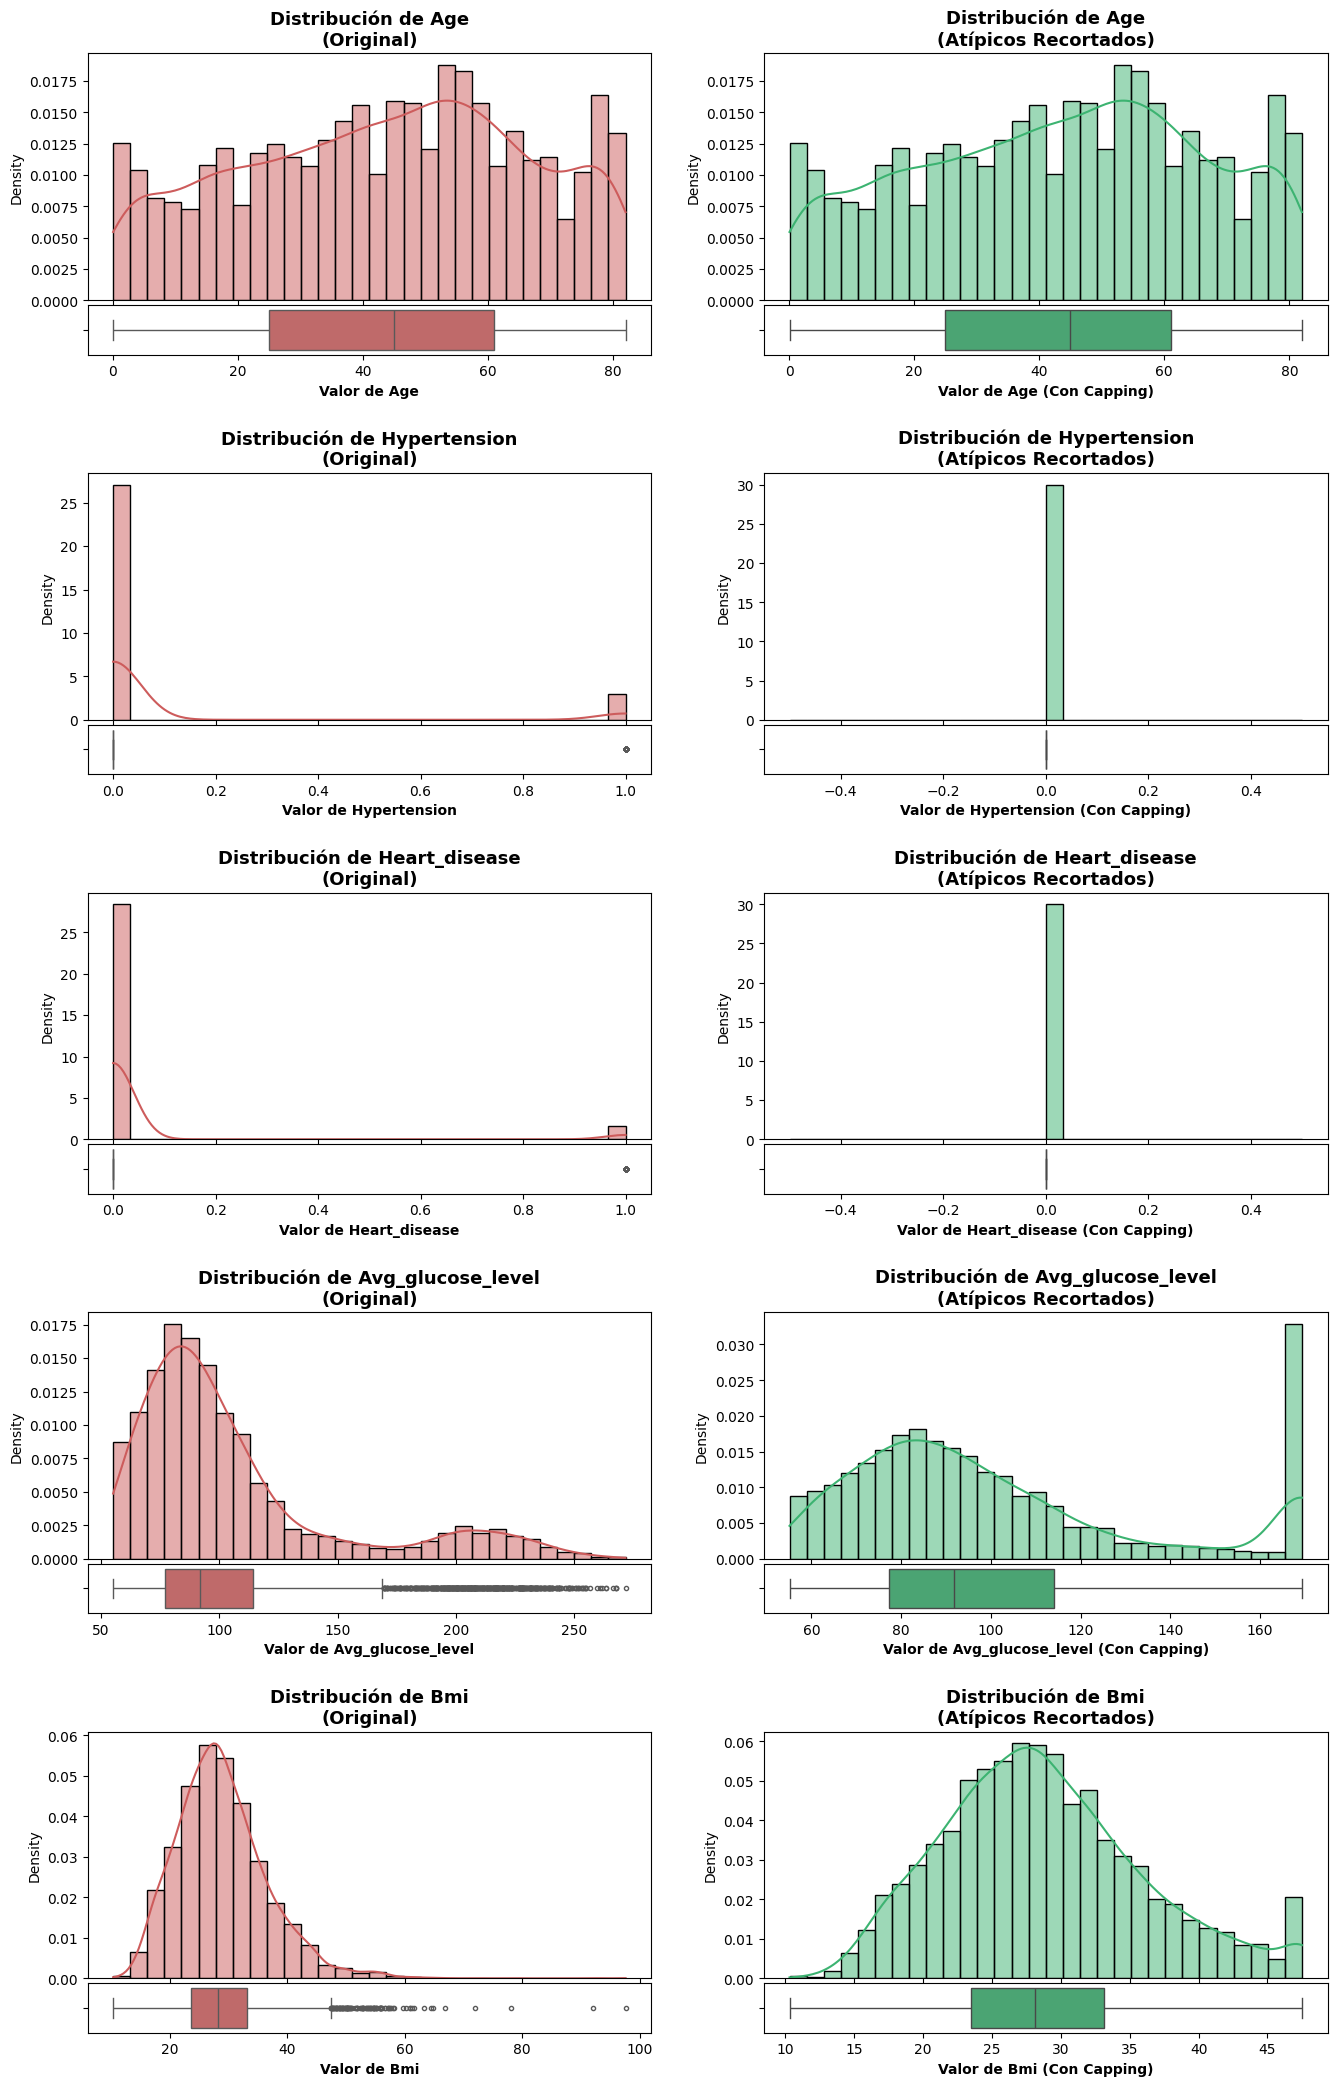

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Asegurar que el directorio de salida exista para no tener errores FileNotFoundError
os.makedirs('../outputs/graficos', exist_ok=True)

# 1. Identificar TODAS las variables numéricas automáticamente
numerical_cols = df.select_dtypes(include=['number']).columns

# ADAPTACIÓN: Excluimos 'id' (identificador) y 'stroke' (variable objetivo)
numerical_cols = [col for col in numerical_cols if col not in ['id', 'stroke']]

# 2. Creamos copia y aplicamos Capping a TODAS las columnas numéricas
df_sin_outliers = df.copy()

print("Calculando límites IQR y aplicando recorte (Capping) a todas las variables numéricas...")
for col in numerical_cols:
    # Calculamos el Rango Intercuartílico (IQR)
    Q1 = df_sin_outliers[col].quantile(0.25)
    Q3 = df_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # np.clip reemplaza los valores extremos por los límites inferior y superior
    df_sin_outliers[col] = np.clip(df_sin_outliers[col], lower_bound, upper_bound)

print(f"Registros originales: {len(df)}")
print(f"Registros tras el tratamiento: {len(df_sin_outliers)} (¡Sin perder pacientes!)\n")
print("-" * 50)

# 3. Visualización Dinámica Avanzada (Ejes Compartidos)
# Creamos tantas filas como variables numéricas tengamos
fig, axs = plt.subplots(len(numerical_cols), 2, figsize=(16, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):

    nombre_columna = col.capitalize()

    # ===========================================================
    # COLUMNA IZQUIERDA: DATOS ORIGINALES (CON OUTLIERS)
    # ===========================================================
    ax_hist_orig = axs[i, 0]
    ax_hist_orig.set_title(f'Distribución de {nombre_columna}\n(Original)', fontweight='bold', fontsize=13)

    # Histograma
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax_hist_orig, color='indianred', stat='density')

    # EL TRUCO: Ocultar textos y números del eje X del histograma
    ax_hist_orig.set_xlabel('')
    ax_hist_orig.tick_params(labelbottom=False)

    # Boxplot (ancho 100%, altura 20%, posicionado justo debajo)
    ax_box_orig = ax_hist_orig.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=df[col].dropna(), ax=ax_box_orig, color='indianred', fliersize=3)

    # EL TRUCO: Forzar al boxplot a tener la misma escala exacta que el histograma
    ax_box_orig.set_xlim(ax_hist_orig.get_xlim())
    ax_box_orig.set_xlabel(f'Valor de {nombre_columna}', fontweight='bold')

    # ===========================================================
    # COLUMNA DERECHA: DATOS RECORTADOS (CAPPING)
    # ===========================================================
    ax_hist_cap = axs[i, 1]
    ax_hist_cap.set_title(f'Distribución de {nombre_columna}\n(Atípicos Recortados)', fontweight='bold', fontsize=13)

    # Histograma
    sns.histplot(df_sin_outliers[col].dropna(), bins=30, kde=True, ax=ax_hist_cap, color='mediumseagreen', stat='density')

    # EL TRUCO: Ocultar textos y números del eje X del histograma
    ax_hist_cap.set_xlabel('')
    ax_hist_cap.tick_params(labelbottom=False)

    # Boxplot
    ax_box_cap = ax_hist_cap.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=df_sin_outliers[col].dropna(), ax=ax_box_cap, color='mediumseagreen', fliersize=3)

    # EL TRUCO: Forzar al boxplot a tener la misma escala exacta que el histograma
    ax_box_cap.set_xlim(ax_hist_cap.get_xlim())
    ax_box_cap.set_xlabel(f'Valor de {nombre_columna} (Con Capping)', fontweight='bold')

# Ajustar márgenes para que los boxplots inferiores no choquen con el título de la siguiente fila
plt.subplots_adjust(hspace=0.7)

# ADAPTACIÓN OBLIGATORIA: Guardar el gráfico
plt.savefig('../outputs/graficos/comparacion_outliers_capping.png', dpi=300, bbox_inches='tight')

plt.show()

**Análisis e Interpretación de Outliers y Limpieza:** 
La decisión técnica de aplicar **Capping (Winsorization a través de límites IQR)** se justifica porque variables metabólicas como el nivel de glucosa o índice de masa corporal continúan siendo fisiológicamente probables aunque presenten valores extremos. Al utilizar `np.clip` logramos mitigar el sesgo y ruido estadístico sistemático que afectaría y arrastraría métricas robustas de entrenamiento, todo esto **SIN perder** valiosos pacientes minoritarios de nuestro dataset médico.

## 6. Correlación

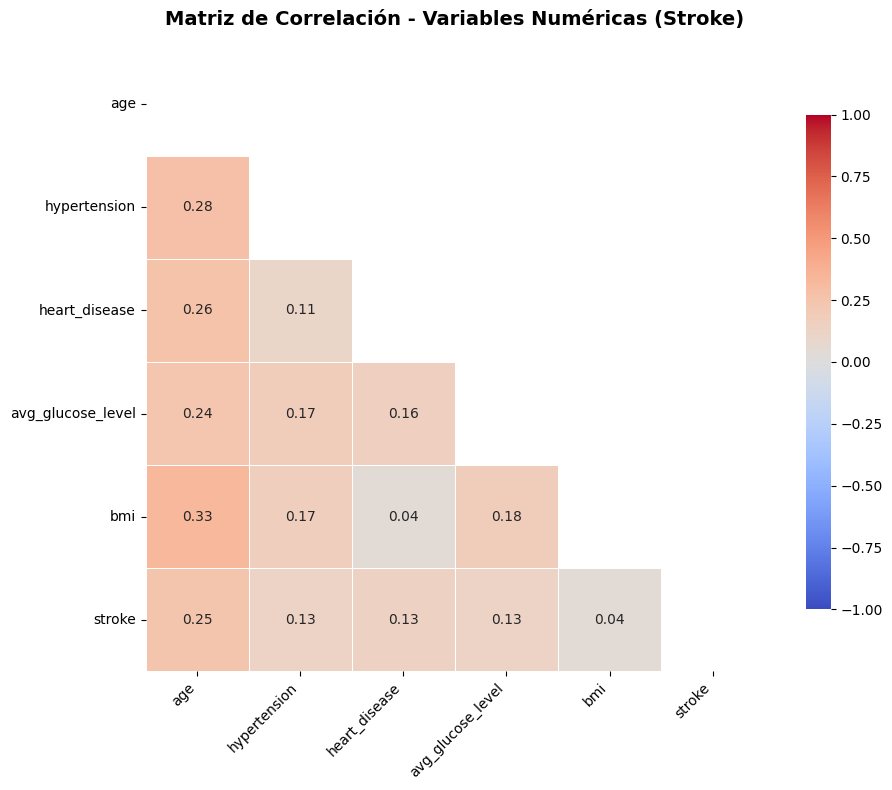

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Aseguramos que la carpeta exista para evitar el FileNotFoundError
os.makedirs('../outputs/graficos', exist_ok=True)

# 1. Seleccionar solo las variables numéricas del dataset
# ADAPTACIÓN: Excluimos 'id' porque es un identificador sin valor estadístico/predictivo
num_cols_corr = df.select_dtypes(include=['number']).columns
num_cols_corr = [c for c in num_cols_corr if c != 'id']

# 2. Calcular la matriz de correlación de Pearson
matriz_correlacion = df[num_cols_corr].corr()

# --- EL TRUCO VISUAL: Crear una máscara para el triángulo superior ---
# np.triu_indices_from devuelve los índices del triángulo superior para ocultar datos duplicados
mask = np.zeros_like(matriz_correlacion, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# 3. Configurar la visualización
plt.figure(figsize=(10, 8))

# Generar un Heatmap aplicando la máscara (mask=mask)
sns.heatmap(matriz_correlacion,
            mask=mask,               # <--- Aplicamos la máscara aquí
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={"shrink": .8})

# ADAPTACIÓN: Título contextualizado a tu proyecto
plt.title("Matriz de Correlación - Variables Numéricas (Stroke)", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# ADAPTACIÓN OBLIGATORIA: Guardar el gráfico para el informe técnico
plt.savefig('../outputs/graficos/matriz_correlacion_mask.png', dpi=300, bbox_inches='tight')

plt.show()


**Análisis e Interpretación de Correlaciones:** 
La matriz de correlación evidencia que la mayor correlación positiva lineal con nuestro target `stroke` la ostenta la variable `age` (edad). Adicionalmente, verificamos una correlación estructural esperable, pero destacable, entre `age` y `bmi` o niveles de glucosa, confirmando el aspecto biológico con la progresión de la adultez media. No se observan multicolinealidades redundantes extremas, evitando la potencial ceguera a predictores independientes.

## 7. Manipulación Avanzada de Datos (Pandas)
A continuación aplicaremos operaciones de agrupaciones múltiples y filtrado complejo evaluando combinaciones mediante métodos nativos avanzados (`loc`, `query`, `groupby` con `agg`). Esta manipulación nos permite obtener un perfilado estadístico granular que complementa los estudios univariables y bivariables.

In [18]:
# Filtrado Avanzado: Encontrar perfiles adultos en etapa de riesgo o madurez y cruzar métricas
analisis_cruzado = (
    df.query("age >= 35 & gender in ['Male', 'Female']")
    .groupby(['work_type', 'gender'])[['avg_glucose_level', 'bmi']]
    .agg(['mean', 'max', 'count'])
)

print("---- Perfil Metabólico Cruzado (Glucosa y BMI) según Trabajo y Género en Adultez (>=35 años) ----")
display(analisis_cruzado.dropna().round(2))

---- Perfil Metabólico Cruzado (Glucosa y BMI) según Trabajo y Género en Adultez (>=35 años) ----


avg_glucose_level                          bmi  \
                                  mean         max count       mean   
work_type     gender                                                  
Govt_job      Female        107.519997  266.589996   333  30.520000   
              Male          116.480003  253.929993   221  31.299999   
Private       Female        110.809998  267.760010  1139  31.120001   
              Male          115.820000  271.739990   828  31.090000   
Self-employed Female        110.760002  267.609985   460  29.830000   
              Male          120.269997  252.720001   284  31.309999   

                                       
                            max count  
work_type     gender                   
Govt_job      Female  57.200001   321  
              Male    57.700001   211  
Private       Female  66.800003  1101  
              Male    92.000000   776  
Self-employed Female  56.000000   435  
              Male    64.800003   267

## HALLAZGOS EDA PARA EL PIPELINE

A partir del presente análisis, y sirviendo como insumo y entregable técnico fundamental de nuestro rol para las etapas siguientes, se definen los tratamientos a incorporar en los pipelines:

- **Columnas a dropear:**
  - `id`: Debe ser eliminada inmediatamente del flujo de inferencia ya que representa únicamente un identificador administrativo carente de cualquier valor descriptivo predictivo.
  - *Si al aplicar el DropZeroVarianceTransformer detectamos variables con nula varianza estadística, estas deberán purgarse igual (Ej. variables genéricas que todos comparten).* 

- **Estrategias de Imputación de Nulos:**
  - **Categóricas:** Deben canalizarse con la inserción de la categoría de texto `'missing'` nativamente mediante un `SimpleImputer`. Esto asume que la "ausencia de la respuesta" es cualitativa y puede retener poder predictivo.
  - **Numéricas:** Dada la alta asimetría probada y el sesgo a la derecha visualizado, imputar utilizando promedios aritméticos clásicos representaría un grave riesgo. Se requiere utilizar robustez y elegir la estrategia de la mediana `SimpleImputer(strategy='median')`.

- **Variables para Encoding Categorical:**
  - Variables binarias (nominales de 2 vías como `ever_married` y `Residence_type`, al igual que `gender`) precisarán ser llevadas a representaciones de ceros y unos (`LabelEncoder` u `OrdinalEncoder`).
  - Variables multi-estado nominales (como `work_type` y `smoking_status`) deben ser distribuidas equitativamente a dimensiones independientes. Implementar obligatoriamente un componente de tipo paramétrico `OneHotEncoder` de Scikit-Learn.

- **Límites de Capping:**
  - Se determinó el uso obligatorio de Capping restrictivo del atípico extremo en base al método de límites de **Rango Intercuartílico (IQR) con un salto estándar de 1.5 en factor** contra los percentiles poblacionales. Todo registro límite por encima de `upper_bound` pasará a ser truncado a el para salvar su peso ponderal y evitar descartar la fila, sobre variables altamente impactadas por outliers como `avg_glucose_level` y `bmi`.